# MMIP: HW3

學號：315831012 姓名：陳芊綺

## Quiz 1: 準備資料集

1. 資料集名稱：The Oxford-IIIT Pet Dataset
2. 資料來源及內容
    - 資料來源：https://www.kaggle.com/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/data
    - 該資料集包含37種貓狗類別（12種貓、25種狗）
    - 每個類別約有200張圖片
    - 共7390張圖片
3. 問題定義：給定一張寵物影像，自動判斷為何品種
4. 分類任務：單標籤多類別分類（single-label, multi-class），輸入為 RGB 影像（統一縮放至 224×224），輸出為 37 個品種的機率分佈，取機率最高者為預測結果

### 資料集統計
1. **測試集**：每個品種隨機抽出 15%，共 1109 張
2. **訓練/驗證集**：其餘 6281 張，在每個品種內隨機且平均地分成 5 組(Fold 0~4)，作為 5-Fold 的切分依據
3. **固定切分**：為節省訓練時間並讓各模型公平比較，所有實驗固定以 Fold 0 作為驗證集(train 5,024 張 / val 1,257 張)

- train：5,024 張
- val：1,257 張
- test：1,109 張  

#### 貓 (12 種,2400 張)

| 品種 | 張數 |
|---|---|
| Abyssinian | 200 |
| Bengal | 200 |
| Birman | 200 |
| Bombay | 200 |
| British_Shorthair | 200 |
| Egyptian_Mau | 200 |
| Maine_Coon | 200 |
| Persian | 200 |
| Ragdoll | 200 |
| Russian_Blue | 200 |
| Siamese | 200 |
| Sphynx | 200 |
| **合計** | **2,400** |

#### 狗 (25 種,4990 張)

| 品種 | 張數 |
|---|---|
| american_bulldog | 200 |
| american_pit_bull_terrier | 200 |
| basset_hound | 200 |
| beagle | 200 |
| boxer | 200 |
| chihuahua | 200 |
| english_cocker_spaniel | 200 |
| english_setter | 200 |
| german_shorthaired | 200 |
| great_pyrenees | 200 |
| havanese | 200 |
| japanese_chin | 200 |
| keeshond | 200 |
| leonberger | 200 |
| miniature_pinscher | 200 |
| newfoundland | 200 |
| pomeranian | 200 |
| pug | 200 |
| saint_bernard | 200 |
| samoyed | 200 |
| scottish_terrier | 199 |
| shiba_inu | 200 |
| staffordshire_bull_terrier | 191 |
| wheaten_terrier | 200 |
| yorkshire_terrier | 200 |
| **合計** | **4,990** |

### 切分資料集


In [1]:
import re
import numpy as np
import pandas as pd
from pathlib import Path

rng = np.random.default_rng(42)

data_dir = Path("images")
paths = sorted(data_dir.glob("*.jpg"))

df = pd.DataFrame({
    "path": [str(p) for p in paths],
    "breed": [re.sub(r"_\d+$", "", p.stem) for p in paths], # 去掉檔名最後的 "_數字" 以取得品種名稱
})
df["type"] = df["breed"].str[0].map(lambda c: "cat" if c.isupper() else "dog")
df["label"] = df["breed"].astype("category").cat.codes # 將品種名稱轉換為數字標籤

# 1. 每個品種各自隨機打亂,取 15% 當測試集(分層)
df["split"] = ""
df["fold"] = -1
for breed, g in df.groupby("breed"):
    idx = rng.permutation(g.index.to_numpy())
    n_test = int(round(len(idx) * 0.15))
    df.loc[idx[:n_test], "split"] = "test"

    # 2. 其餘平均分成 5 折(每個品種內輪流分配 → 分層)
    rest = idx[n_test:]
    df.loc[rest, "fold"] = np.arange(len(rest)) % 5

# 3. 固定的 train/val(fold 0 當驗證集)
mask = df["split"] != "test"
df.loc[mask & (df["fold"] == 0), "split"] = "val"
df.loc[mask & (df["fold"] != 0), "split"] = "train"

df.to_csv("split.csv", index=False)

print(df["split"].value_counts())
print(df.groupby(["split", "type"]).size().unstack())

split
train    5024
val      1257
test     1109
Name: count, dtype: int64
type    cat   dog
split            
test    360   749
train  1632  3392
val     408   849


## Quiz 2: 訓練 CNN 影像分類模型

In [2]:
%load_ext autoreload
%autoreload 2
import torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.data import load_split, make_loaders
from src.models import PlainCNN, build_resnet18, count_params
from src.engine import fit, evaluate, predict

device = torch.device("cuda")
df, class_names = load_split()
train_loader, val_loader, test_loader = make_loaders(df, batch_size=32)

Plain CNN 訓練：**Baseline**
- 網路寬度:(32, 64, 128, 256)，共 4 個卷積區塊
- Dropout：0.3
- Epochs：30
- Learning rate：1e-3
- Optimizer：AdamW
- Weight decay：1e-4
- Batch size：32
- 輸入尺寸：224 × 224
- 資料增強：無

In [3]:
plain = PlainCNN()
print(count_params(plain)) # (總參數量, 可訓練參數量)
hist_plain = fit(plain, train_loader, val_loader, device, name="plain_base", epochs=30, lr=1e-3)
print(evaluate(plain, val_loader, device))   # (loss, top1, top5)

(398405, 398405)
[plain_base] ep01/30 loss 3.538 | val loss 3.418 top1 0.077 top5 0.309 | 73s
[plain_base] ep02/30 loss 3.403 | val loss 3.366 top1 0.101 top5 0.328 | 43s
[plain_base] ep03/30 loss 3.301 | val loss 3.220 top1 0.126 top5 0.416 | 36s
[plain_base] ep04/30 loss 3.190 | val loss 3.284 top1 0.107 top5 0.360 | 47s
[plain_base] ep05/30 loss 3.064 | val loss 3.066 top1 0.173 top5 0.475 | 79s
[plain_base] ep06/30 loss 2.968 | val loss 3.201 top1 0.148 top5 0.442 | 30s
[plain_base] ep07/30 loss 2.889 | val loss 2.920 top1 0.190 top5 0.512 | 30s
[plain_base] ep08/30 loss 2.781 | val loss 2.849 top1 0.205 top5 0.548 | 30s
[plain_base] ep09/30 loss 2.721 | val loss 2.771 top1 0.239 top5 0.575 | 30s
[plain_base] ep10/30 loss 2.632 | val loss 2.768 top1 0.242 top5 0.577 | 30s
[plain_base] ep11/30 loss 2.583 | val loss 2.655 top1 0.248 top5 0.628 | 30s
[plain_base] ep12/30 loss 2.493 | val loss 2.692 top1 0.245 top5 0.628 | 30s
[plain_base] ep13/30 loss 2.445 | val loss 2.516 top1 0.320

c:\master\MMIP\HW3\src\engine.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"checkpoints/{name}.pt"))  # 載回最佳權重


(0.0, 0.43675417661097854, 0.7899761336515513)


ResNet 18 訓練：**Baseline**  
- 預訓練權重：ImageNet
- 微調方式：全部微調（Full fine-tuning）
- 分類層：將最後的 fc 層替換為 37 類輸出
- Epochs：15
- Learning rate：3e-4
- Optimizer：AdamW
- Weight decay：1e-4
- Batch size：32
- 輸入尺寸：224 × 224
- 資料增強：無

In [23]:
resnet = build_resnet18()
hist_res = fit(resnet, train_loader, val_loader, device, name="resnet18_base", epochs=15, lr=3e-4)

[resnet18_base] ep01/15 loss 1.003 | val loss 0.825 top1 0.746 top5 0.963 | 42s
[resnet18_base] ep02/15 loss 0.228 | val loss 0.477 top1 0.848 top5 0.983 | 46s
[resnet18_base] ep03/15 loss 0.088 | val loss 0.438 top1 0.871 top5 0.990 | 76s
[resnet18_base] ep04/15 loss 0.023 | val loss 0.407 top1 0.887 top5 0.992 | 44s
[resnet18_base] ep05/15 loss 0.019 | val loss 0.403 top1 0.881 top5 0.990 | 47s
[resnet18_base] ep06/15 loss 0.017 | val loss 0.349 top1 0.898 top5 0.993 | 40s
[resnet18_base] ep07/15 loss 0.009 | val loss 0.335 top1 0.901 top5 0.990 | 38s
[resnet18_base] ep08/15 loss 0.003 | val loss 0.311 top1 0.907 top5 0.991 | 38s
[resnet18_base] ep09/15 loss 0.003 | val loss 0.306 top1 0.910 top5 0.992 | 53s
[resnet18_base] ep10/15 loss 0.002 | val loss 0.297 top1 0.913 top5 0.992 | 45s
[resnet18_base] ep11/15 loss 0.002 | val loss 0.294 top1 0.911 top5 0.992 | 73s
[resnet18_base] ep12/15 loss 0.001 | val loss 0.296 top1 0.911 top5 0.993 | 65s
[resnet18_base] ep13/15 loss 0.001 | val

c:\master\MMIP\HW3\src\engine.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"checkpoints/{name}.pt"))  # 載回最佳權重


載入最佳訓練權重：

In [24]:
plain = PlainCNN().to(device)
plain.load_state_dict(torch.load("checkpoints/plain_base.pt", weights_only=True))
resnet = build_resnet18(pretrained=False).to(device)
resnet.load_state_dict(torch.load("checkpoints/resnet18_base.pt", weights_only=True))

<All keys matched successfully>

Plain CNN 與 ResNet 18 訓練曲線：

In [25]:
import json
json.dump(hist_plain, open("results/hist_plain_base.json", "w"))
json.dump(hist_res, open("results/hist_resnet18_base.json", "w"))

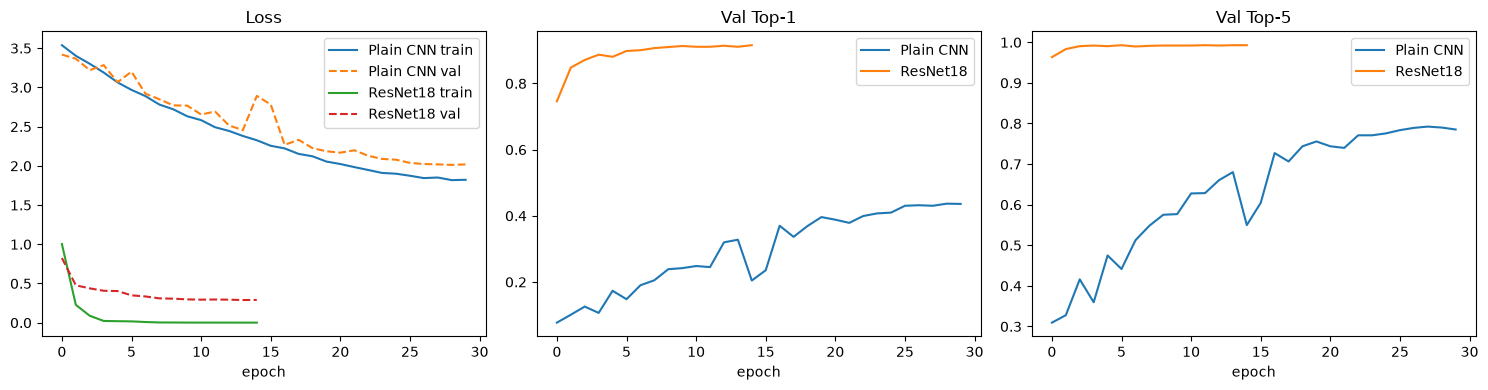

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for h, n in [(hist_plain, "Plain CNN"), (hist_res, "ResNet18")]:
    axes[0].plot(h["train_loss"], label=f"{n} train"); axes[0].plot(h["val_loss"], "--", label=f"{n} val")
    axes[1].plot(h["val_top1"], label=n); axes[2].plot(h["val_top5"], label=n)
for ax, t in zip(axes, ["Loss", "Val Top-1", "Val Top-5"]):
    ax.set_title(t); ax.set_xlabel("epoch"); ax.legend()
plt.tight_layout(); plt.savefig("results/training_curves.png", dpi=150); plt.show()

預測 Test Dataset 並比較兩者 Top-1 & Top-5：

In [27]:
import os
os.makedirs("results", exist_ok=True)
test_df = df[df["split"] == "test"].reset_index(drop=True) # 使用test split的資料

def run_test(model, tag):
    probs, y = predict(model, test_loader, device)
    pred = probs.argmax(1)
    top5 = np.argsort(-probs, axis=1)[:, :5]
    top1_acc = (pred == y).mean()
    top5_acc = np.mean([y[i] in top5[i] for i in range(len(y))])
    res = pd.DataFrame({
        "path": test_df["path"],
        "true": [class_names[i] for i in y],
        "pred": [class_names[i] for i in pred],
        "confidence": probs.max(1).round(4),
        "correct": pred == y,
    })
    res.to_csv(f"results/{tag}_test_pred.csv", index=False)
    np.save(f"results/{tag}_test_probs.npy", probs)
    np.save("results/test_labels.npy", y)
    print(f"{tag}: Test Top-1 {top1_acc:.4f} | Top-5 {top5_acc:.4f}")
    return probs, y, top1_acc, top5_acc

p_plain, y_test, a1_plain, a5_plain = run_test(plain, "plain")
p_res,   _,      a1_res,   a5_res   = run_test(resnet, "resnet18")

plain: Test Top-1 0.4274 | Top-5 0.7917
resnet18: Test Top-1 0.9098 | Top-5 0.9901


用 numpy 算 ROC 與 Macro-AUC：

In [28]:
def roc_curve_np(y_bin, score):
    order = np.argsort(-score, kind="mergesort")
    y = y_bin[order]
    tps, fps = np.cumsum(y), np.cumsum(1 - y)
    tpr = np.r_[0, tps / tps[-1]]
    fpr = np.r_[0, fps / fps[-1]]
    return fpr, tpr

def auc_np(fpr, tpr):
    return float(np.sum((fpr[1:] - fpr[:-1]) * (tpr[1:] + tpr[:-1]) / 2))

def roc_all(probs, y, n_cls=37):
    grid = np.linspace(0, 1, 201)
    curves, aucs, tprs = [], [], []
    for c in range(n_cls):
        fpr, tpr = roc_curve_np((y == c).astype(int), probs[:, c])
        curves.append((fpr, tpr)); aucs.append(auc_np(fpr, tpr))
        tprs.append(np.interp(grid, fpr, tpr))
    macro_curve = (grid, np.mean(tprs, axis=0))
    return curves, np.array(aucs), macro_curve

curves_p, auc_p, macro_p = roc_all(p_plain, y_test)
curves_r, auc_r, macro_r = roc_all(p_res, y_test)
print(f"Macro-AUC  Plain CNN: {auc_p.mean():.4f} | ResNet18: {auc_r.mean():.4f}")

Macro-AUC  Plain CNN: 0.9255 | ResNet18: 0.9969


畫 ROC Curve

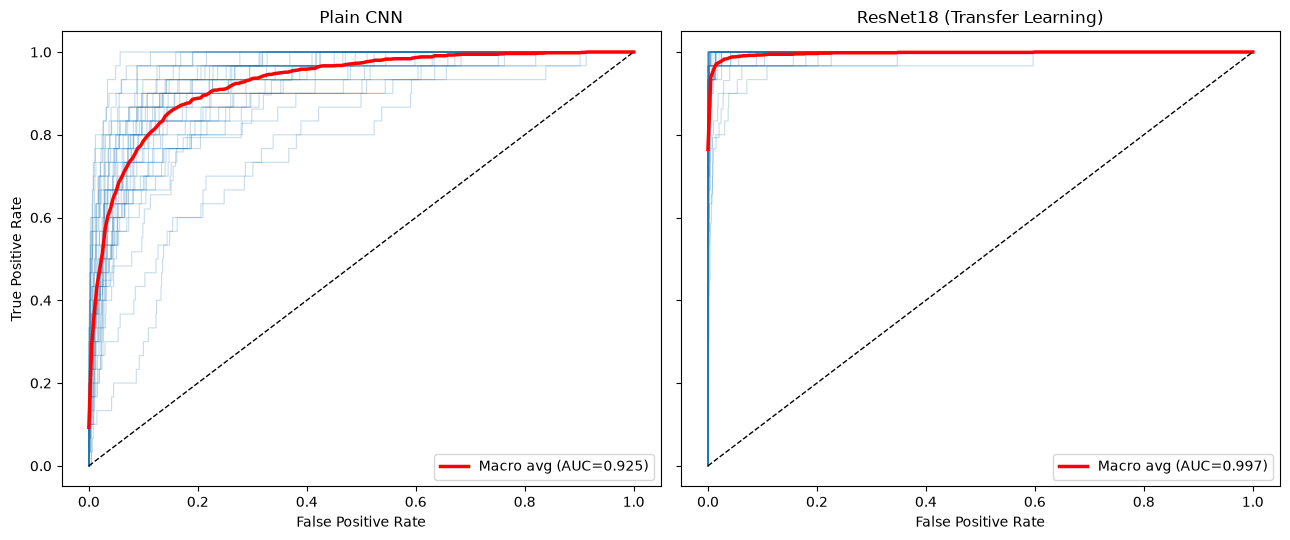

Plain CNN 表現最差的 8 個品種:


,breed,plain_auc,resnet18_auc
17,chihuahua,0.772907,0.998363
13,american_pit_bull_terrier,0.788353,0.987087
29,pug,0.871053,0.999444
10,Siamese,0.883040,0.996664
18,english_cocker_spaniel,0.884121,0.999876
34,staffordshire_bull_terrier,0.884930,0.991315
12,american_bulldog,0.886222,0.985758
33,shiba_inu,0.892493,0.999938


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
for ax, curves, aucs, macro, title in [
    (axes[0], curves_p, auc_p, macro_p, "Plain CNN"),
    (axes[1], curves_r, auc_r, macro_r, "ResNet18 (Transfer Learning)")]:
    for (fpr, tpr) in curves:
        ax.plot(fpr, tpr, color="tab:blue", alpha=0.25, lw=0.8)
    ax.plot(*macro, color="red", lw=2.5, label=f"Macro avg (AUC={aucs.mean():.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title(title); ax.set_xlabel("False Positive Rate"); ax.legend(loc="lower right")
axes[0].set_ylabel("True Positive Rate")
plt.tight_layout(); plt.savefig("results/roc_curves.png", dpi=150); plt.show()
auc_df = pd.DataFrame({"breed": class_names, "plain_auc": auc_p, "resnet18_auc": auc_r})
print("Plain CNN 表現最差的 8 個品種:")
display(auc_df.sort_values("plain_auc").head(8)) # Plain CNN 表現最差的 8 個品種

比較表（Macro-AUC、Accuracy 與 參數量大小）

In [30]:
tp, _ = count_params(plain)
tr, _ = count_params(resnet)
cmp = pd.DataFrame({
    "Model": ["Plain CNN", "ResNet18 (pretrained)"],
    "Params (M)": [tp / 1e6, tr / 1e6],
    "Test Top-1": [a1_plain, a1_res],
    "Test Top-5": [a5_plain, a5_res],
    "Macro-AUC": [auc_p.mean(), auc_r.mean()],
}).round(4)
cmp.to_csv("results/model_comparison.csv", index=False)
display(cmp)

,Model,Params (M),Test Top-1,Test Top-5,Macro-AUC
0,Plain CNN,0.3984,0.4274,0.7917,0.9255
1,ResNet18 (pretrained),11.1955,0.9098,0.9901,0.9969


### 進階：針對 Plain CNN 實驗不同的超參數設定

實驗設計：
1. Learning Rate：3e-3 / 1e-3 (baseline) / 3e-4
2. Network width：(32, 64, 128, 256) (baseline) / (64, 128, 256, 512)
3. Dropout rate：0 / 0.3 (baseline) / 0.5
4. Batch size：32 (baseline) / 64

In [12]:
import os, json, time, torch
os.makedirs("results/exp", exist_ok=True)

# 依 batch size 建立並快取 DataLoader
_loader_cache = {}
def get_loaders(bs):
    if bs not in _loader_cache:
        _loader_cache[bs] = make_loaders(df, batch_size=bs)
    return _loader_cache[bs]

# 跑一組實驗:訓練 → 記錄 → 存 JSON;已完成的會自動跳過
def run_exp(name, build, epochs, batch_size=32, **fit_kw):
    path = f"results/exp/{name}.json"
    if os.path.exists(path):
        print(f"[skip] {name} 已完成"); return json.load(open(path))
    tr_loader, va_loader, _ = get_loaders(batch_size)
    model = build()
    total, trainable = count_params(model)
    t0 = time.time()
    hist = fit(model, tr_loader, va_loader, device, name=name, epochs=epochs, **fit_kw)
    best = max(range(epochs), key=lambda i: hist["val_top1"][i])
    rec = {"name": name, "batch_size": batch_size, **{k: str(v) for k, v in fit_kw.items()},
           "params_M": total / 1e6, "trainable_M": trainable / 1e6,
           "best_val_top1": hist["val_top1"][best], "best_val_top5": hist["val_top5"][best],
           "best_epoch": best + 1, "final_train_loss": hist["train_loss"][-1],
           "min_val_loss": min(hist["val_loss"]), "minutes": (time.time() - t0) / 60,
           "hist": hist}
    json.dump(rec, open(path, "w"))
    del model; torch.cuda.empty_cache()
    return rec

# 整理成比較表
def summarize(recs):
    cols = ["name", "params_M", "best_val_top1", "best_val_top5", "best_epoch",
            "final_train_loss", "min_val_loss", "minutes"]
    return pd.DataFrame([{k: r[k] for k in cols} for r in recs]).round(4)

# 畫比較圖:Val Top-1、Val Top-5、Loss(實線 train,虛線 val)
def plot_group(recs, title, fname):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    colors = plt.cm.tab10.colors
    for i, r in enumerate(recs):
        c = colors[i % 10]; h = r["hist"]
        axes[0].plot(h["val_top1"], color=c, label=r["name"])
        axes[1].plot(h["val_top5"], color=c, label=r["name"])
        axes[2].plot(h["train_loss"], color=c, label=f'{r["name"]} train')
        axes[2].plot(h["val_loss"], "--", color=c, label=f'{r["name"]} val')
    for ax, t in zip(axes, ["Val Top-1", "Val Top-5", "Loss (solid=train, dashed=val)"]):
        ax.set_title(f"{title}: {t}"); ax.set_xlabel("epoch")
    axes[0].legend(fontsize=8); axes[1].legend(fontsize=8); axes[2].legend(fontsize=7, ncol=2)
    plt.tight_layout(); plt.savefig(f"results/{fname}", dpi=150); plt.show()

In [13]:
P_EPOCHS = 30
src_path = "results/hist_plain_base.json"
dst_path = "results/exp/exp_plain_base.json"

if os.path.exists(dst_path):
    print("baseline 已轉存過,略過")
elif os.path.exists(src_path):
    h = json.load(open(src_path))
    if len(h["val_top1"]) == P_EPOCHS:
        best = max(range(P_EPOCHS), key=lambda i: h["val_top1"][i])
        total, trainable = count_params(PlainCNN())
        rec = {"name": "exp_plain_base", "batch_size": 32, "lr": "0.001",
               "params_M": total / 1e6, "trainable_M": trainable / 1e6,
               "best_val_top1": h["val_top1"][best], "best_val_top5": h["val_top5"][best],
               "best_epoch": best + 1, "final_train_loss": h["train_loss"][-1],
               "min_val_loss": min(h["val_loss"]), "minutes": float("nan"), "hist": h}
        json.dump(rec, open(dst_path, "w"))
        print("baseline 已轉存,best val top1 =", round(rec["best_val_top1"], 4))
    else:
        print(f"baseline 只有 {len(h['val_top1'])} 個 epoch,與 {P_EPOCHS} 不符,Cell 3 會重跑 baseline")
else:
    print("找不到 baseline 紀錄,Cell 3 會重跑 baseline")

baseline 已轉存,best val top1 = 0.4368


訓練 Plain CNN 不同的超參數：

In [ ]:
plain_exps = [
    # (名稱, 建立模型, 設定)
    ("exp_plain_base",    lambda: PlainCNN(),                           dict(lr=1e-3)),
    # 1. Learning rate
    ("exp_plain_lr3e-3",  lambda: PlainCNN(),                           dict(lr=3e-3)), # 0.001 → 0.003
    ("exp_plain_lr3e-4",  lambda: PlainCNN(),                           dict(lr=3e-4)), # 0.001 → 0.0003
    # 2. Network width
    ("exp_plain_wide",    lambda: PlainCNN(widths=(64, 128, 256, 512)), dict(lr=1e-3)),
    # 3. Dropout
    ("exp_plain_drop0",   lambda: PlainCNN(dropout=0.0),                dict(lr=1e-3)),
    ("exp_plain_drop0.5", lambda: PlainCNN(dropout=0.5),                dict(lr=1e-3)),
    # 4. Batch size
    ("exp_plain_bs64",    lambda: PlainCNN(),                           dict(lr=1e-3, batch_size=64)),
]

plain_recs = []
for n, b, kw in plain_exps:
    kw = dict(kw); bs = kw.pop("batch_size", 32)
    plain_recs.append(run_exp(n, b, P_EPOCHS, batch_size=bs, **kw))

display(summarize(plain_recs))

[skip] exp_plain_base 已完成
[exp_plain_lr3e-3] ep01/30 loss 3.616 | val loss 3.532 top1 0.062 top5 0.235 | 47s
[exp_plain_lr3e-3] ep02/30 loss 3.483 | val loss 3.406 top1 0.085 top5 0.318 | 40s
[exp_plain_lr3e-3] ep03/30 loss 3.400 | val loss 3.381 top1 0.080 top5 0.326 | 56s
[exp_plain_lr3e-3] ep04/30 loss 3.299 | val loss 3.478 top1 0.102 top5 0.313 | 41s
[exp_plain_lr3e-3] ep05/30 loss 3.197 | val loss 3.225 top1 0.105 top5 0.398 | 39s
[exp_plain_lr3e-3] ep06/30 loss 3.048 | val loss 3.139 top1 0.139 top5 0.471 | 37s
[exp_plain_lr3e-3] ep07/30 loss 2.939 | val loss 3.087 top1 0.166 top5 0.454 | 33s
[exp_plain_lr3e-3] ep08/30 loss 2.838 | val loss 2.902 top1 0.195 top5 0.524 | 32s
[exp_plain_lr3e-3] ep09/30 loss 2.733 | val loss 2.890 top1 0.199 top5 0.554 | 33s
[exp_plain_lr3e-3] ep10/30 loss 2.631 | val loss 2.742 top1 0.231 top5 0.593 | 32s
[exp_plain_lr3e-3] ep11/30 loss 2.523 | val loss 2.655 top1 0.258 top5 0.631 | 31s
[exp_plain_lr3e-3] ep12/30 loss 2.449 | val loss 2.819 top1 0

c:\master\MMIP\HW3\src\engine.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"checkpoints/{name}.pt"))  # 載回最佳權重


[exp_plain_lr3e-4] ep01/30 loss 3.543 | val loss 3.419 top1 0.079 top5 0.323 | 30s
[exp_plain_lr3e-4] ep02/30 loss 3.415 | val loss 3.355 top1 0.090 top5 0.362 | 31s
[exp_plain_lr3e-4] ep03/30 loss 3.345 | val loss 3.313 top1 0.115 top5 0.383 | 30s
[exp_plain_lr3e-4] ep04/30 loss 3.279 | val loss 3.275 top1 0.126 top5 0.392 | 30s
[exp_plain_lr3e-4] ep05/30 loss 3.211 | val loss 3.192 top1 0.145 top5 0.430 | 30s
[exp_plain_lr3e-4] ep06/30 loss 3.156 | val loss 3.141 top1 0.153 top5 0.437 | 30s
[exp_plain_lr3e-4] ep07/30 loss 3.090 | val loss 3.049 top1 0.173 top5 0.497 | 30s
[exp_plain_lr3e-4] ep08/30 loss 3.033 | val loss 3.023 top1 0.181 top5 0.503 | 30s
[exp_plain_lr3e-4] ep09/30 loss 2.975 | val loss 3.028 top1 0.182 top5 0.496 | 30s
[exp_plain_lr3e-4] ep10/30 loss 2.935 | val loss 2.920 top1 0.228 top5 0.548 | 30s
[exp_plain_lr3e-4] ep11/30 loss 2.869 | val loss 2.964 top1 0.190 top5 0.507 | 30s
[exp_plain_lr3e-4] ep12/30 loss 2.824 | val loss 3.016 top1 0.185 top5 0.508 | 31s
[exp

c:\master\MMIP\HW3\src\engine.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"checkpoints/{name}.pt"))  # 載回最佳權重


,name,params_M,best_val_top1,best_val_top5,best_epoch,final_train_loss,min_val_loss,minutes
0,exp_plain_base,0.3984,0.4368,0.7900,29,1.8223,2.0122,NaN
1,exp_plain_lr3e-3,0.3984,0.4901,0.8258,29,1.5323,1.7756,16.4163
2,exp_plain_lr3e-4,0.3984,0.3294,0.6770,27,2.3749,2.4849,16.4443
3,exp_plain_wide,1.5709,0.4702,0.8067,30,1.5332,1.8791,21.3304
4,exp_plain_drop0,0.3984,0.4463,0.7860,28,1.5621,1.9902,17.2310
5,exp_plain_drop0.5,0.3984,0.4002,0.7597,28,2.1340,2.1737,18.8780
6,exp_plain_bs64,0.3984,0.4193,0.7709,30,1.9487,2.1288,14.8918


依參數分別畫圖：

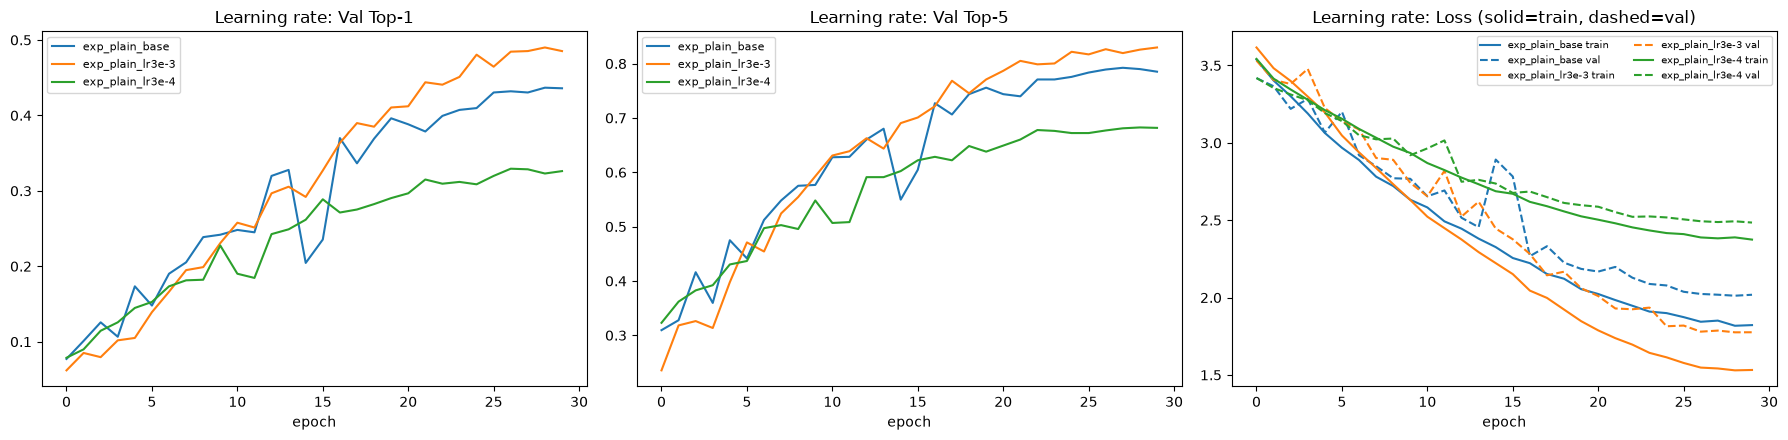

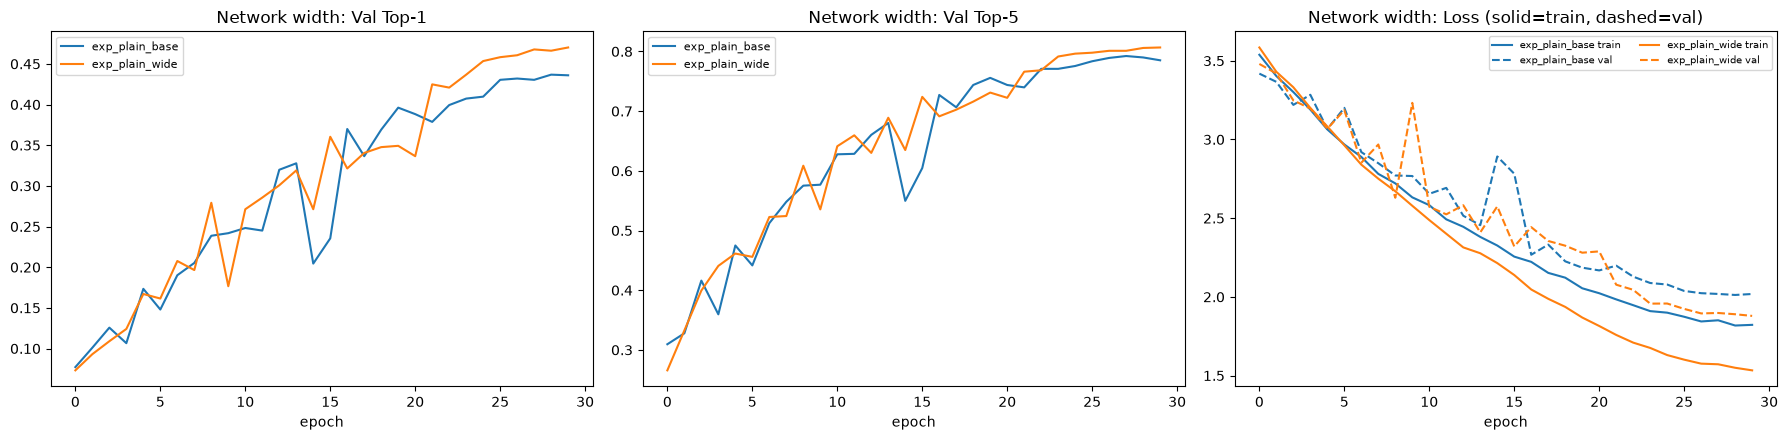

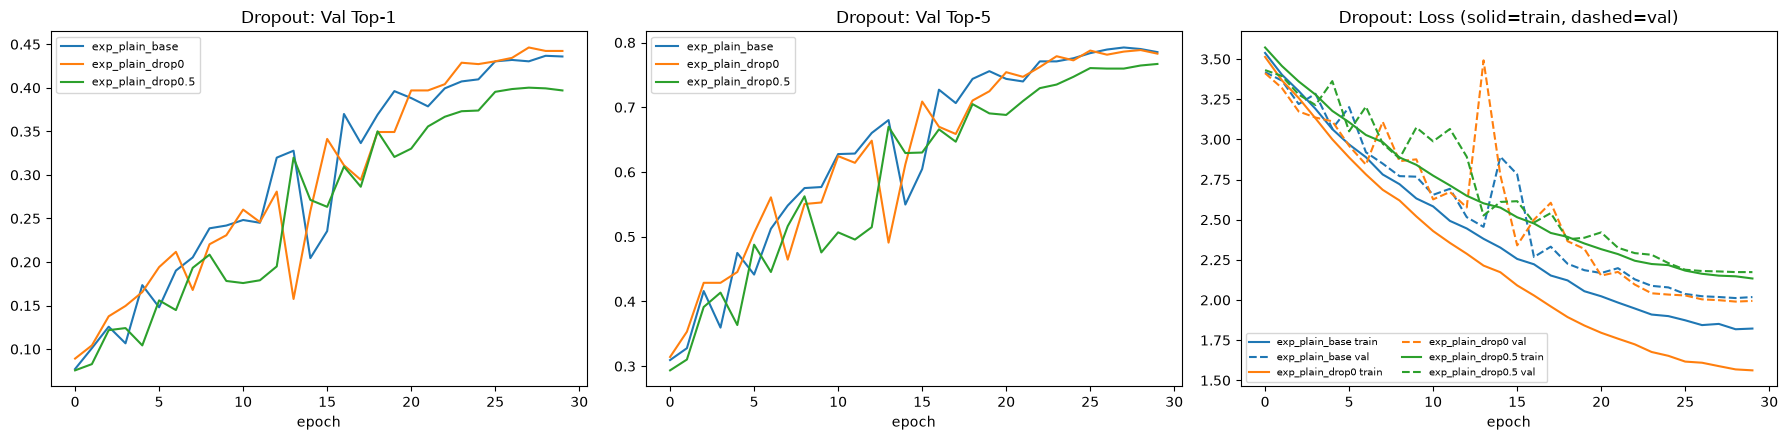

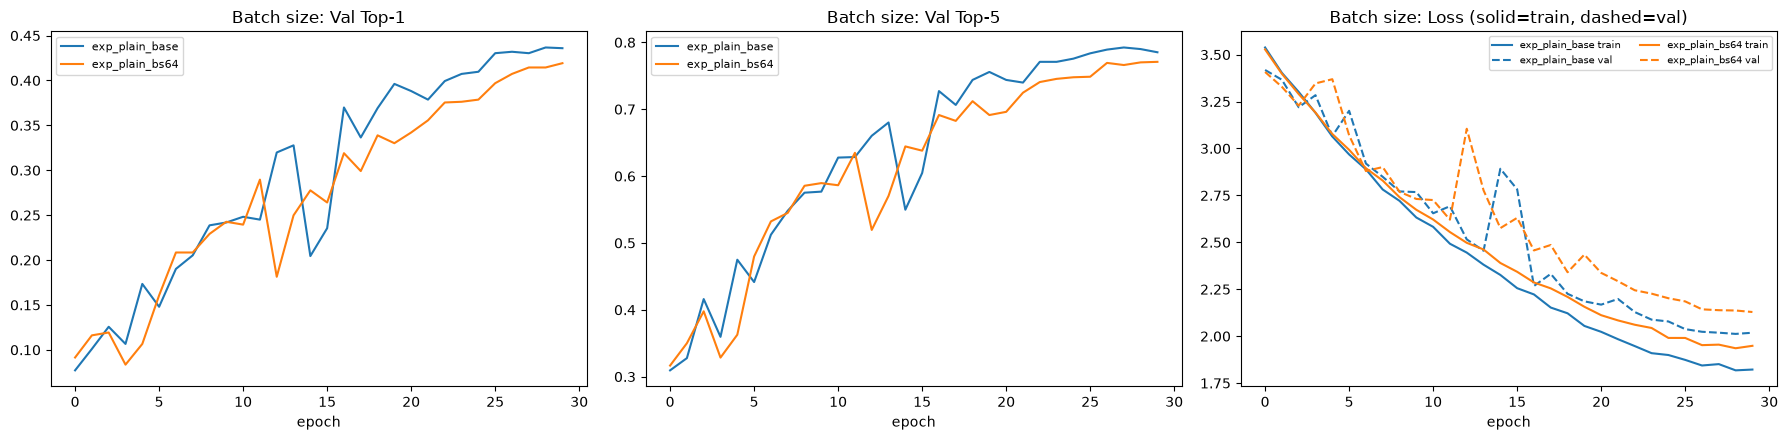

In [15]:
r = {x["name"]: x for x in plain_recs}
base = r["exp_plain_base"]
plot_group([base, r["exp_plain_lr3e-3"], r["exp_plain_lr3e-4"]], "Learning rate", "exp_plain_lr.png")
plot_group([base, r["exp_plain_wide"]],                         "Network width", "exp_plain_width.png")
plot_group([base, r["exp_plain_drop0"], r["exp_plain_drop0.5"]], "Dropout",      "exp_plain_dropout.png")
plot_group([base, r["exp_plain_bs64"]],                         "Batch size",    "exp_plain_bs.png")

結果分析：
- Learning Rate = 3e - 3 時，val top-1 及 val top-5 都表現得最好，loss也是表現的最低的
- Network width 加寬後，val top-1 比 baseline 上升了 0.0334，val top-5 比 baseline 上升 0.0167，loss 從數據及圖表來看也明顯下降
- Dropout = 0.5 時 val top-1 降至 0.4002，train loss 上升至 2.13，過強的正則化讓原本已欠擬合的模型學得更少，Dropout = 0 時 Val Top-1 僅小幅提升至 0.4463，但 train/val loss 反而上升，因此 0.3 是較平衡的選擇
- Batch size = 64 時 val top-1 降至 0.4193，在相同 epochs 下，batch 加倍代表參數更新次數減半，在學習率未同步調整的情況下，模型學得較少，train loss 也較高，若要公平比較 batch，通常需同時提高學習率

最佳組合lr=3e-3 + widths=(64, 128, 256, 512) + dropout 0.3 + batch 32：
val top-1 = 0.5139 是所有組合中表現最佳的，train loss = 1.2952 相比 baseline 大大下降了 0.53，val loss = 1.7206 相比 baseline 下降了 0.29


[exp_plain_best] ep01/30 loss 3.713 | val loss 3.599 top1 0.053 top5 0.234 | 64s
[exp_plain_best] ep02/30 loss 3.563 | val loss 3.500 top1 0.065 top5 0.256 | 47s
[exp_plain_best] ep03/30 loss 3.481 | val loss 3.569 top1 0.080 top5 0.247 | 53s
[exp_plain_best] ep04/30 loss 3.405 | val loss 3.387 top1 0.093 top5 0.324 | 44s
[exp_plain_best] ep05/30 loss 3.321 | val loss 3.316 top1 0.126 top5 0.368 | 43s
[exp_plain_best] ep06/30 loss 3.229 | val loss 3.378 top1 0.088 top5 0.344 | 43s
[exp_plain_best] ep07/30 loss 3.110 | val loss 3.096 top1 0.140 top5 0.470 | 42s
[exp_plain_best] ep08/30 loss 2.972 | val loss 3.060 top1 0.174 top5 0.477 | 44s
[exp_plain_best] ep09/30 loss 2.827 | val loss 2.868 top1 0.213 top5 0.551 | 45s
[exp_plain_best] ep10/30 loss 2.741 | val loss 3.008 top1 0.175 top5 0.501 | 48s
[exp_plain_best] ep11/30 loss 2.612 | val loss 2.856 top1 0.231 top5 0.586 | 48s
[exp_plain_best] ep12/30 loss 2.504 | val loss 2.563 top1 0.302 top5 0.633 | 43s
[exp_plain_best] ep13/30 los

c:\master\MMIP\HW3\src\engine.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"checkpoints/{name}.pt"))  # 載回最佳權重


,name,params_M,best_val_top1,best_val_top5,best_epoch,final_train_loss,min_val_loss,minutes
0,exp_plain_base,0.3984,0.4368,0.7900,29,1.8223,2.0122,NaN
1,exp_plain_lr3e-3,0.3984,0.4901,0.8258,29,1.5323,1.7756,16.4163
2,exp_plain_lr3e-4,0.3984,0.3294,0.6770,27,2.3749,2.4849,16.4443
3,exp_plain_wide,1.5709,0.4702,0.8067,30,1.5332,1.8791,21.3304
4,exp_plain_drop0,0.3984,0.4463,0.7860,28,1.5621,1.9902,17.2310
5,exp_plain_drop0.5,0.3984,0.4002,0.7597,28,2.1340,2.1737,18.8780
6,exp_plain_bs64,0.3984,0.4193,0.7709,30,1.9487,2.1288,14.8918
7,exp_plain_best,1.5709,0.5139,0.8337,30,1.2952,1.7206,22.1095


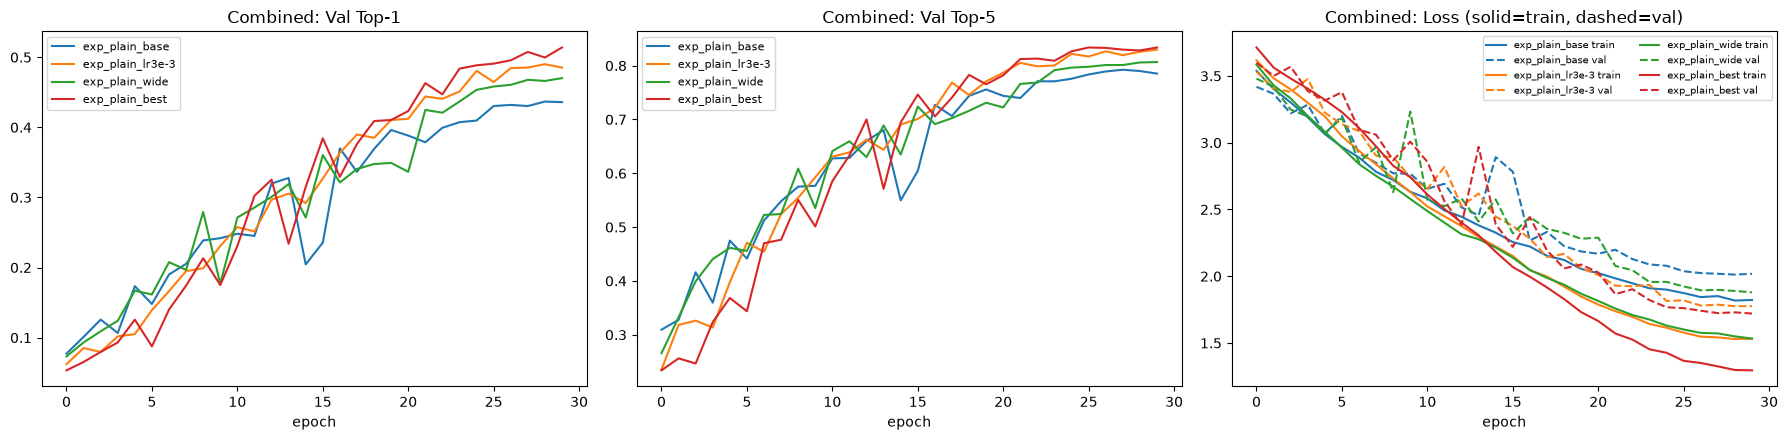

In [16]:
best_rec = run_exp("exp_plain_best",
                   lambda: PlainCNN(widths=(64, 128, 256, 512)),
                   P_EPOCHS, lr=3e-3)
plain_recs.append(best_rec)
display(summarize(plain_recs))
plot_group([r["exp_plain_base"], r["exp_plain_lr3e-3"], r["exp_plain_wide"], best_rec],
           "Combined", "exp_plain_combined.png")

### 進階：針對 ResNet 18 實驗不同的超參數設定

實驗設計：
1. Fine-tuning 策略：全部微調(baseline) / 凍結 backbone
2. Learning Rate：3e-3(baseline) / 1e-3 / 3e-4
3. Optimizer：AdamW(baseline) / SGD (lr=1e-2, momentum 0.9)
4. Label smoothing：0(baseline) / 0.1
5. 預訓練權重：ImageNet 預訓練(baseline) / 隨機初始化

訓練 ResNet 18 不同的超參數：

In [18]:
R_EPOCHS = 15
res_exps = [
    # (名稱, 建立模型, 設定)
    ("exp_res_base",    lambda: build_resnet18(),                      dict(lr=3e-4)),
    # 1. Fine-tuning 策略
    ("exp_res_freeze",  lambda: build_resnet18(freeze_backbone=True),  dict(lr=1e-3)),
    # 2. Learning rate
    ("exp_res_lr1e-3",  lambda: build_resnet18(),                      dict(lr=1e-3)),
    ("exp_res_lr1e-4",  lambda: build_resnet18(),                      dict(lr=1e-4)),
    # 3. Optimizer
    ("exp_res_sgd",     lambda: build_resnet18(),                      dict(lr=1e-2, optimizer="sgd")),
    # 4. Label smoothing
    ("exp_res_ls0.1",   lambda: build_resnet18(),                      dict(lr=3e-4, label_smoothing=0.1)),
    # 5. 預訓練權重
    ("exp_res_scratch", lambda: build_resnet18(pretrained=False),      dict(lr=1e-3)),
]

res_recs = []
for n, b, kw in res_exps:
    kw = dict(kw); bs = kw.pop("batch_size", 32)
    res_recs.append(run_exp(n, b, R_EPOCHS, batch_size=bs, **kw))

display(summarize(res_recs)[["name", "params_M", "best_val_top1", "best_val_top5",
                             "best_epoch", "final_train_loss", "min_val_loss", "minutes"]])
print(pd.DataFrame([{"name": x["name"], "trainable_M": round(x["trainable_M"], 4)} for x in res_recs]))

[exp_res_base] ep01/15 loss 1.012 | val loss 0.600 top1 0.815 top5 0.984 | 72s
[exp_res_base] ep02/15 loss 0.221 | val loss 0.554 top1 0.835 top5 0.984 | 56s
[exp_res_base] ep03/15 loss 0.061 | val loss 0.416 top1 0.871 top5 0.988 | 44s
[exp_res_base] ep04/15 loss 0.035 | val loss 0.381 top1 0.896 top5 0.987 | 46s
[exp_res_base] ep05/15 loss 0.021 | val loss 0.388 top1 0.883 top5 0.990 | 89s
[exp_res_base] ep06/15 loss 0.011 | val loss 0.373 top1 0.901 top5 0.990 | 79s
[exp_res_base] ep07/15 loss 0.004 | val loss 0.307 top1 0.913 top5 0.990 | 84s
[exp_res_base] ep08/15 loss 0.002 | val loss 0.297 top1 0.914 top5 0.990 | 45s
[exp_res_base] ep09/15 loss 0.002 | val loss 0.283 top1 0.917 top5 0.991 | 40s
[exp_res_base] ep10/15 loss 0.001 | val loss 0.284 top1 0.916 top5 0.991 | 38s
[exp_res_base] ep11/15 loss 0.001 | val loss 0.290 top1 0.918 top5 0.991 | 42s
[exp_res_base] ep12/15 loss 0.001 | val loss 0.291 top1 0.914 top5 0.991 | 35s
[exp_res_base] ep13/15 loss 0.001 | val loss 0.283 t

c:\master\MMIP\HW3\src\engine.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"checkpoints/{name}.pt"))  # 載回最佳權重


[exp_res_freeze] ep01/15 loss 1.652 | val loss 0.738 top1 0.846 top5 0.988 | 38s
[exp_res_freeze] ep02/15 loss 0.630 | val loss 0.486 top1 0.883 top5 0.994 | 33s
[exp_res_freeze] ep03/15 loss 0.455 | val loss 0.419 top1 0.881 top5 0.992 | 39s
[exp_res_freeze] ep04/15 loss 0.384 | val loss 0.375 top1 0.905 top5 0.993 | 36s
[exp_res_freeze] ep05/15 loss 0.330 | val loss 0.363 top1 0.889 top5 0.993 | 31s
[exp_res_freeze] ep06/15 loss 0.287 | val loss 0.350 top1 0.898 top5 0.992 | 30s
[exp_res_freeze] ep07/15 loss 0.264 | val loss 0.334 top1 0.897 top5 0.994 | 27s
[exp_res_freeze] ep08/15 loss 0.244 | val loss 0.320 top1 0.903 top5 0.990 | 28s
[exp_res_freeze] ep09/15 loss 0.228 | val loss 0.324 top1 0.904 top5 0.992 | 28s
[exp_res_freeze] ep10/15 loss 0.214 | val loss 0.315 top1 0.905 top5 0.993 | 27s
[exp_res_freeze] ep11/15 loss 0.204 | val loss 0.316 top1 0.901 top5 0.993 | 27s
[exp_res_freeze] ep12/15 loss 0.202 | val loss 0.311 top1 0.904 top5 0.994 | 27s
[exp_res_freeze] ep13/15 los

,name,params_M,best_val_top1,best_val_top5,best_epoch,final_train_loss,min_val_loss,minutes
0,exp_res_base,11.1955,0.9204,0.9912,13,0.0011,0.2797,12.9895
1,exp_res_freeze,11.1955,0.9053,0.9928,4,0.1926,0.3075,7.5577
2,exp_res_lr1e-3,11.1955,0.8624,0.9809,14,0.0012,0.4899,8.4091
3,exp_res_lr1e-4,11.1955,0.9364,0.9952,9,0.0041,0.2422,8.8459
4,exp_res_sgd,11.1955,0.9117,0.9889,15,0.0019,0.2915,9.3385
5,exp_res_ls0.1,11.1955,0.9284,0.9897,14,0.6800,0.9731,8.5756
6,exp_res_scratch,11.1955,0.4694,0.8146,14,0.2599,1.8547,8.2559


              name  trainable_M
0     exp_res_base      11.1955
1   exp_res_freeze       0.0190
2   exp_res_lr1e-3      11.1955
3   exp_res_lr1e-4      11.1955
4      exp_res_sgd      11.1955
5    exp_res_ls0.1      11.1955
6  exp_res_scratch      11.1955


依參數分別畫圖：

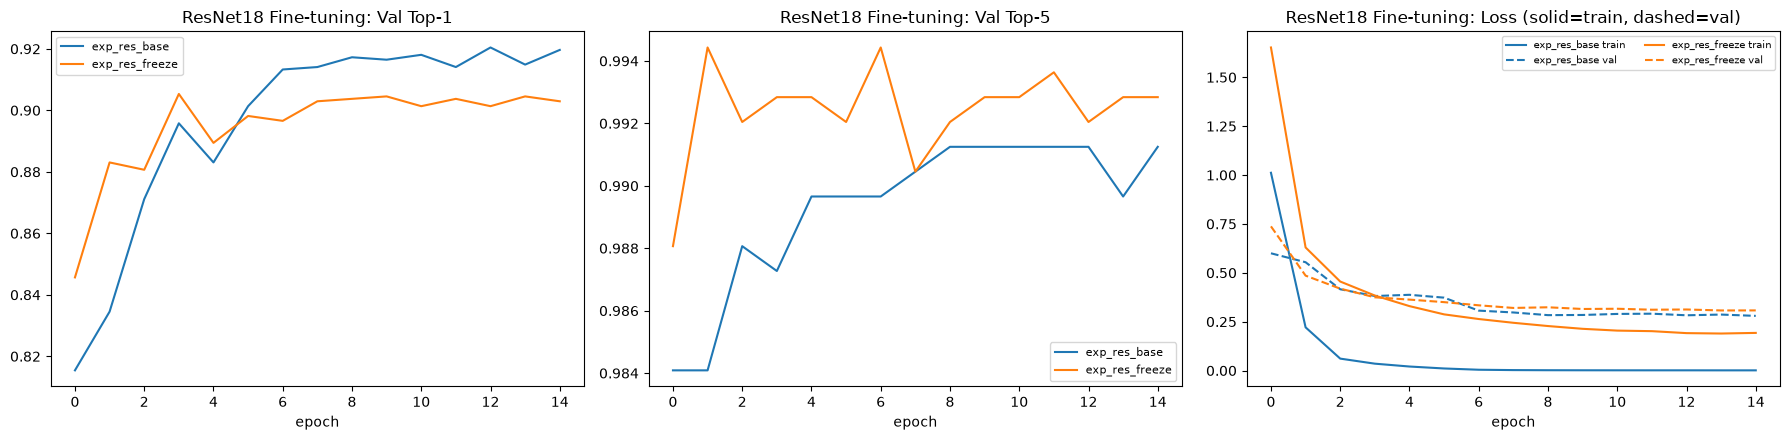

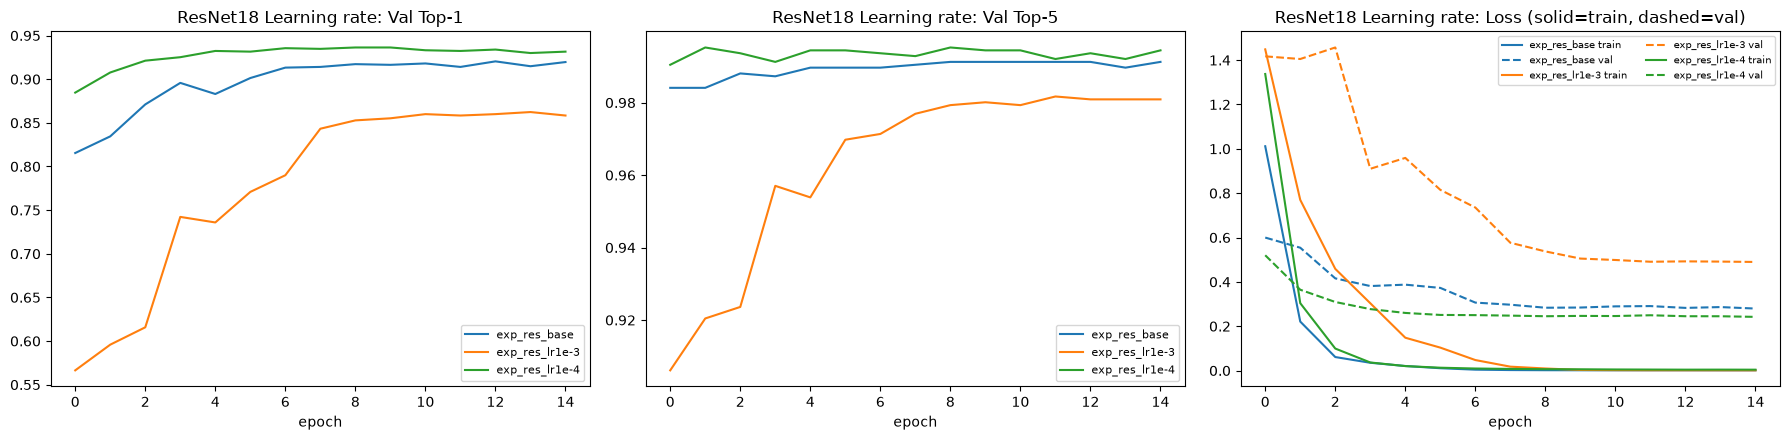

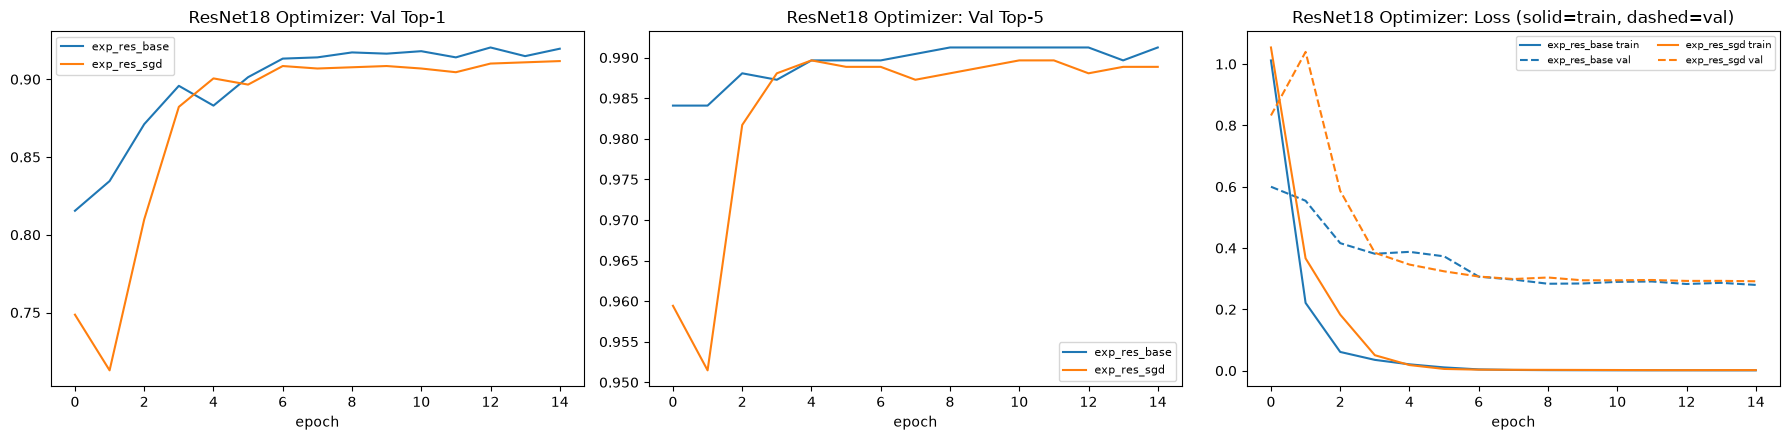

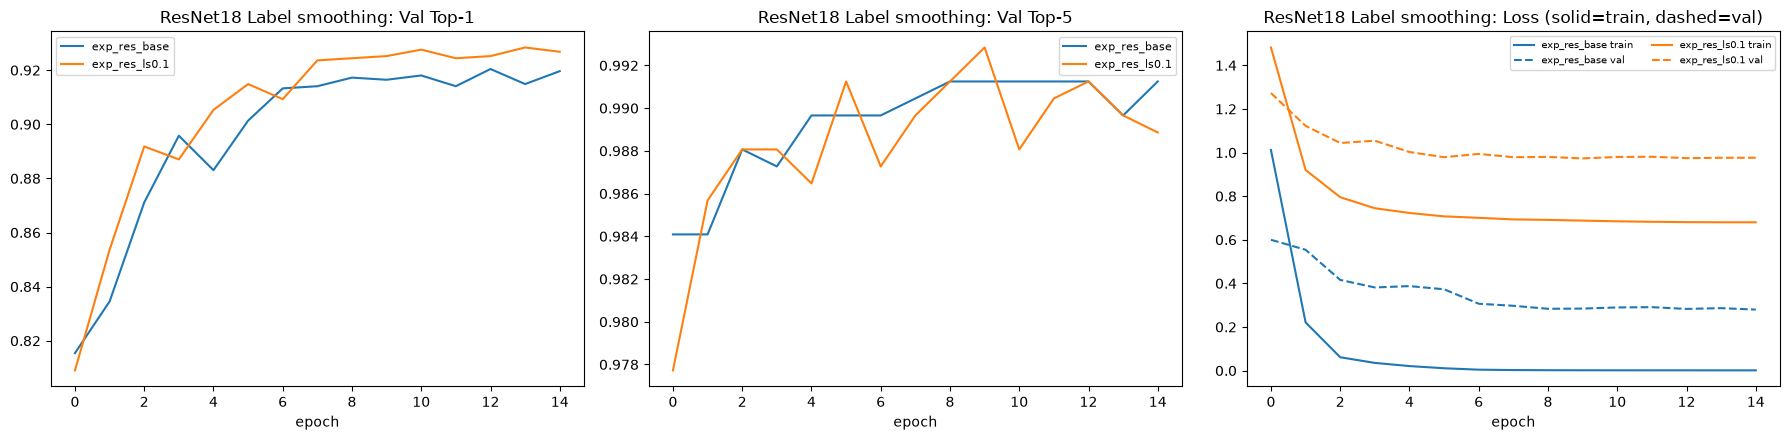

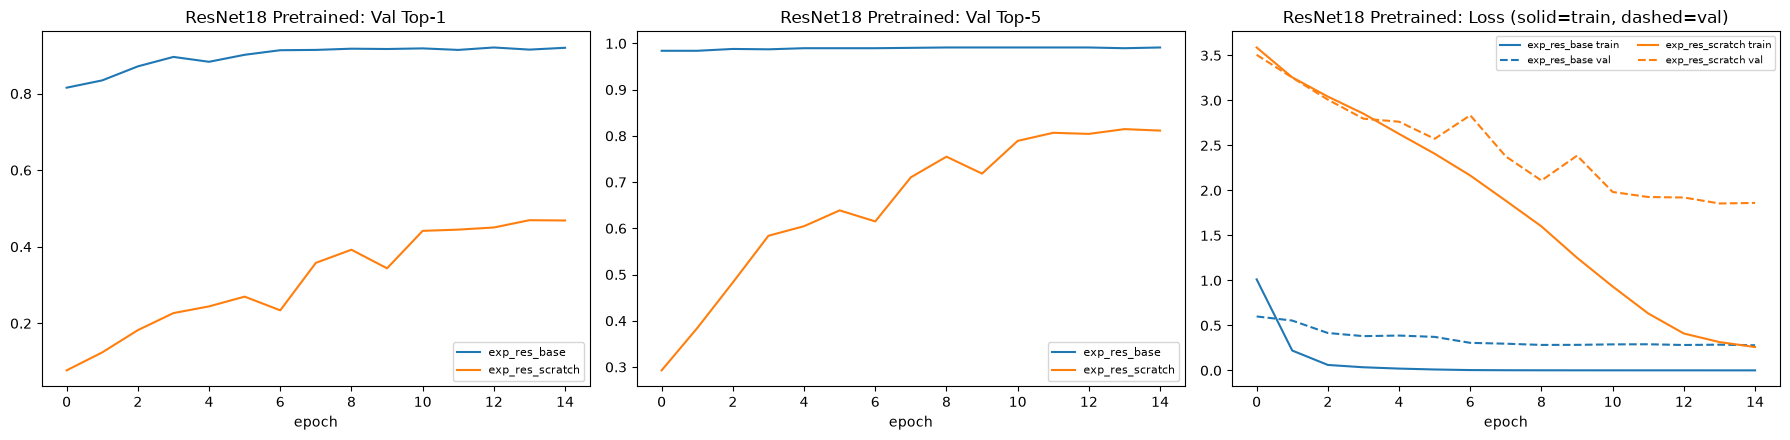

In [19]:
rr = {x["name"]: x for x in res_recs}
rb = rr["exp_res_base"]
plot_group([rb, rr["exp_res_freeze"]],                       "ResNet18 Fine-tuning",  "exp_res_freeze.png")
plot_group([rb, rr["exp_res_lr1e-3"], rr["exp_res_lr1e-4"]], "ResNet18 Learning rate", "exp_res_lr.png")
plot_group([rb, rr["exp_res_sgd"]],                          "ResNet18 Optimizer",    "exp_res_opt.png")
plot_group([rb, rr["exp_res_ls0.1"]],                        "ResNet18 Label smoothing", "exp_res_ls.png")
plot_group([rb, rr["exp_res_scratch"]],                      "ResNet18 Pretrained",   "exp_res_scratch.png")

結果分析：
- freeze 只訓練約 0.02M 參數，val top-1 僅比全部微調低約 1.5%，顯示 ImageNet 的預訓練特徵對寵物分類已經非常有用
- Learning Rate = 1e-4 的 val top-1 表現得比其餘兩者還好，學習率太大會破壞原本的特徵
- SGD 與 AdamW 表現相近
- Label smoothing 讓 Val Top-1 小幅提升約 0.8%(92.0% → 92.8%)，其 loss 較高是因標籤平滑使 loss 無法降到 0
- 不使用預訓練時 val top-1 大幅下降到 46.9%，和 Plain CNN 差不多，說明 ResNet18 的高準確率主要來自預訓練

## Quiz 3: 提升泛化能力

擴增策略：
- RandomResizedCrop：隨機裁切原圖 70% - 100% 並縮放到 224x224
- RandomHorizontalFlip：50% 機率左右翻轉
- RandomRotation：隨機旋轉 −15° 至 +15° 的範圍
- ColorJitter：隨機調整亮度、對比、飽和度 -20% 至 +20% 的範圍

圖片增強

In [ ]:
from torchvision import transforms
from src.data import MEAN, STD

aug_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)), # 隨機裁切並縮放到 224x224, scale=(0.7,1.0) 表示裁切面積佔原圖的 70%~100%
    transforms.RandomHorizontalFlip(), # 隨機水平翻轉
    transforms.RandomRotation(15), # 隨機旋轉 ±15 度
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # 隨機調整亮度、對比、飽和度
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

_loader_cache = {}
def get_loaders(bs, aug=False):
    key = (bs, aug)
    if key not in _loader_cache:
        _loader_cache[key] = make_loaders(df, batch_size=bs, train_tf=aug_tf if aug else None)
    return _loader_cache[key]

def run_exp(name, build, epochs, batch_size=32, aug=False, **fit_kw):
    path = f"results/exp/{name}.json"
    if os.path.exists(path):
        print(f"[skip] {name} 已完成"); return json.load(open(path))
    tr_loader, va_loader, _ = get_loaders(batch_size, aug)
    model = build()
    total, trainable = count_params(model)
    t0 = time.time()
    hist = fit(model, tr_loader, va_loader, device, name=name, epochs=epochs, **fit_kw)
    best = max(range(epochs), key=lambda i: hist["val_top1"][i])
    rec = {"name": name, "batch_size": batch_size, "aug": aug,
           **{k: str(v) for k, v in fit_kw.items()},
           "params_M": total / 1e6, "trainable_M": trainable / 1e6,
           "best_val_top1": hist["val_top1"][best], "best_val_top5": hist["val_top5"][best],
           "best_epoch": best + 1, "final_train_loss": hist["train_loss"][-1],
           "min_val_loss": min(hist["val_loss"]), "minutes": (time.time() - t0) / 60,
           "hist": hist}
    json.dump(rec, open(path, "w"))
    del model; torch.cuda.empty_cache()
    return rec

圖片示範

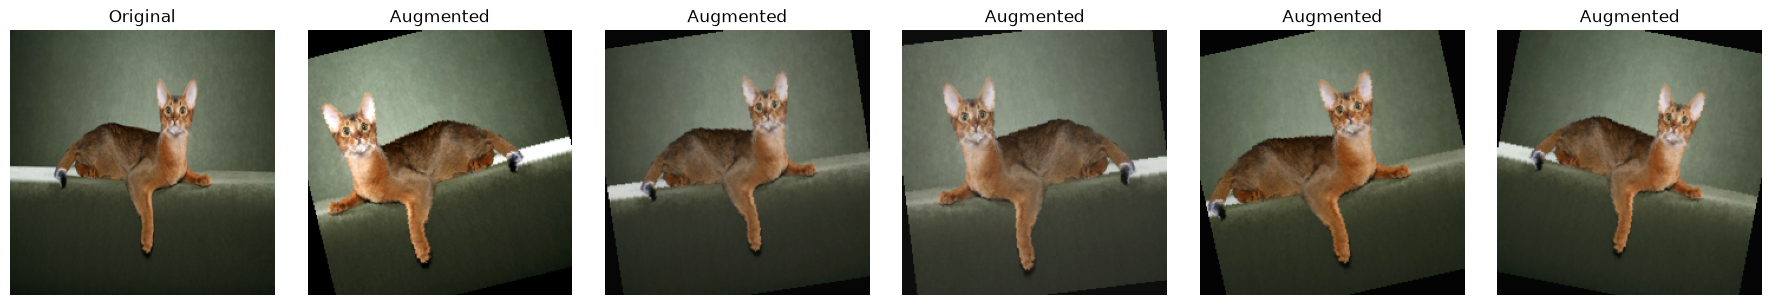

In [33]:
from PIL import Image
sample = Image.open(df[df["split"] == "train"]["path"].iloc[0]).convert("RGB")
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
axes[0].imshow(sample.resize((224, 224))); axes[0].set_title("Original")
mean, std = torch.tensor(MEAN).view(3, 1, 1), torch.tensor(STD).view(3, 1, 1)
for ax in axes[1:]:
    x = aug_tf(sample) * std + mean                      # 還原正規化以便顯示
    ax.imshow(x.permute(1, 2, 0).clamp(0, 1)); ax.set_title("Augmented")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.savefig("results/aug_examples.png", dpi=150); plt.show()

Plain CNN 與 ResNet18 加入 Data Augmentation

[skip] exp_plain_base 已完成
[aug_plain] ep01/30 loss 3.551 | val loss 3.463 top1 0.069 top5 0.267 | 80s
[aug_plain] ep02/30 loss 3.427 | val loss 3.382 top1 0.101 top5 0.329 | 64s
[aug_plain] ep03/30 loss 3.349 | val loss 3.528 top1 0.055 top5 0.259 | 56s
[aug_plain] ep04/30 loss 3.277 | val loss 3.201 top1 0.123 top5 0.422 | 64s
[aug_plain] ep05/30 loss 3.194 | val loss 3.232 top1 0.122 top5 0.402 | 76s
[aug_plain] ep06/30 loss 3.092 | val loss 3.171 top1 0.132 top5 0.443 | 99s
[aug_plain] ep07/30 loss 3.013 | val loss 3.245 top1 0.115 top5 0.411 | 107s
[aug_plain] ep08/30 loss 2.918 | val loss 2.951 top1 0.196 top5 0.517 | 58s
[aug_plain] ep09/30 loss 2.859 | val loss 2.897 top1 0.190 top5 0.542 | 44s
[aug_plain] ep10/30 loss 2.783 | val loss 2.923 top1 0.199 top5 0.533 | 44s
[aug_plain] ep11/30 loss 2.710 | val loss 2.714 top1 0.242 top5 0.605 | 43s
[aug_plain] ep12/30 loss 2.640 | val loss 2.678 top1 0.255 top5 0.613 | 41s
[aug_plain] ep13/30 loss 2.614 | val loss 2.750 top1 0.230 to

c:\master\MMIP\HW3\src\engine.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"checkpoints/{name}.pt"))  # 載回最佳權重


[aug_res] ep01/15 loss 1.050 | val loss 0.933 top1 0.718 top5 0.955 | 43s
[aug_res] ep02/15 loss 0.464 | val loss 0.586 top1 0.808 top5 0.985 | 43s
[aug_res] ep03/15 loss 0.316 | val loss 0.581 top1 0.816 top5 0.977 | 40s
[aug_res] ep04/15 loss 0.244 | val loss 0.589 top1 0.819 top5 0.968 | 42s
[aug_res] ep05/15 loss 0.175 | val loss 0.430 top1 0.874 top5 0.983 | 41s
[aug_res] ep06/15 loss 0.117 | val loss 0.446 top1 0.864 top5 0.987 | 41s
[aug_res] ep07/15 loss 0.090 | val loss 0.424 top1 0.869 top5 0.990 | 41s
[aug_res] ep08/15 loss 0.049 | val loss 0.461 top1 0.866 top5 0.986 | 40s
[aug_res] ep09/15 loss 0.040 | val loss 0.387 top1 0.880 top5 0.986 | 40s
[aug_res] ep10/15 loss 0.027 | val loss 0.346 top1 0.900 top5 0.988 | 40s
[aug_res] ep11/15 loss 0.020 | val loss 0.336 top1 0.908 top5 0.989 | 40s
[aug_res] ep12/15 loss 0.016 | val loss 0.336 top1 0.909 top5 0.988 | 40s
[aug_res] ep13/15 loss 0.012 | val loss 0.310 top1 0.914 top5 0.991 | 40s
[aug_res] ep14/15 loss 0.012 | val los

,name,params_M,best_val_top1,best_val_top5,best_epoch,final_train_loss,min_val_loss,minutes
0,exp_plain_base,0.3984,0.4368,0.7900,29,1.8223,2.0122,NaN
1,aug_plain,0.3984,0.3842,0.7526,30,2.1169,2.1985,25.9821
2,exp_res_base,11.1955,0.9204,0.9912,13,0.0011,0.2797,12.9895
3,aug_res,11.1955,0.9165,0.9905,14,0.0100,0.3069,10.2657


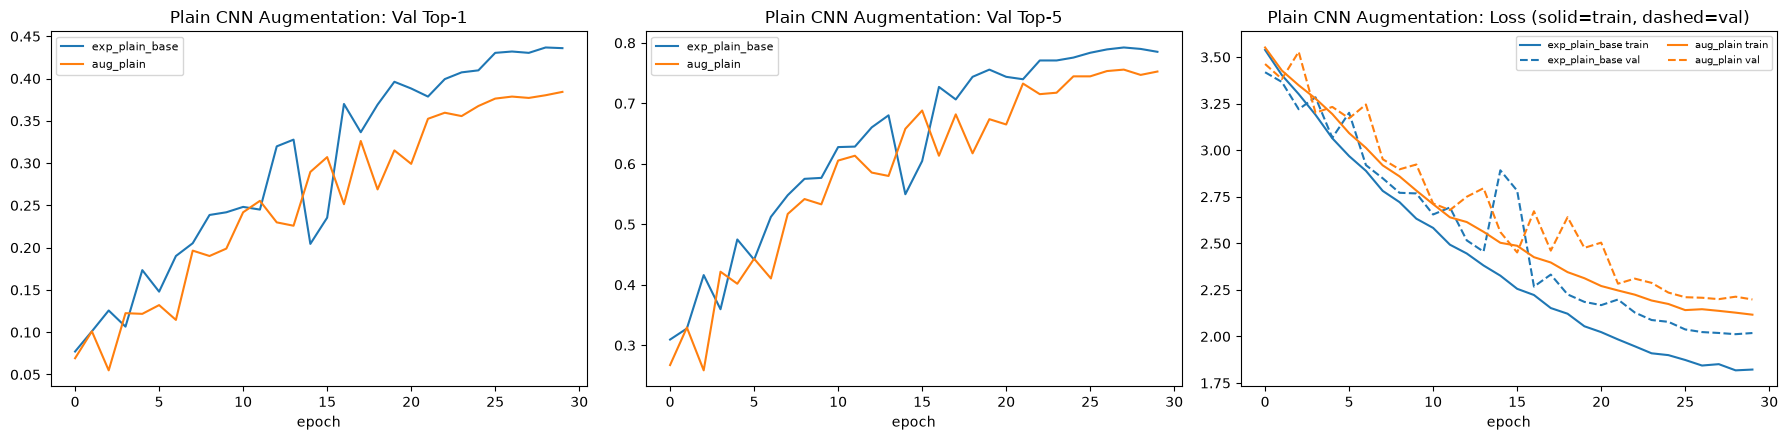

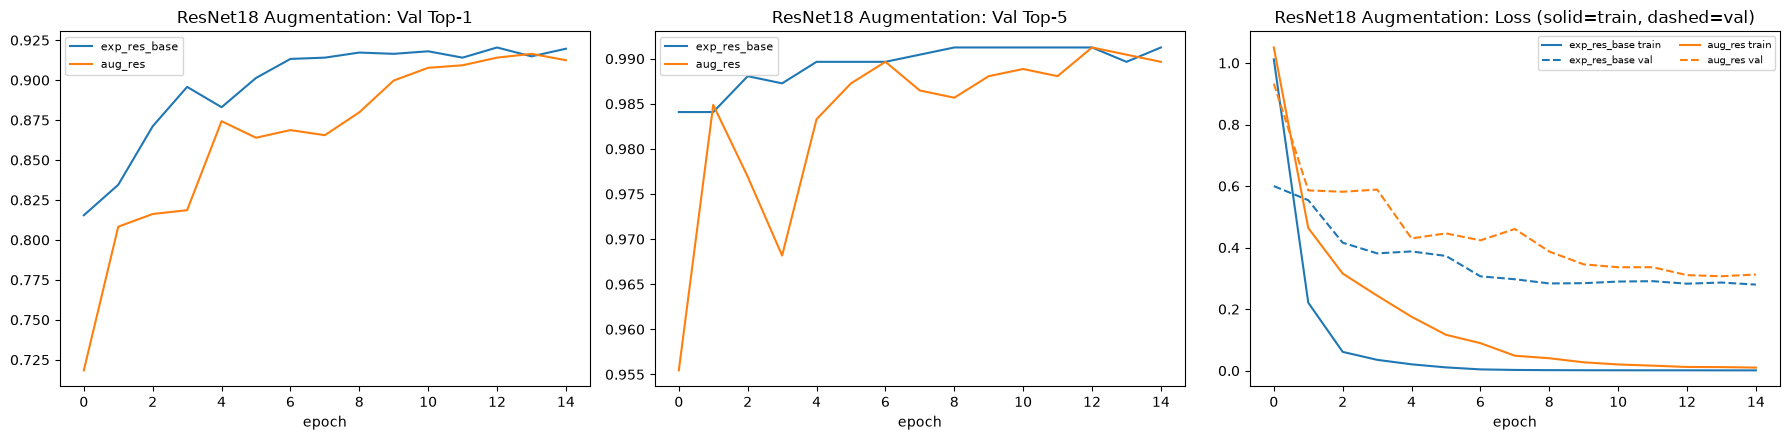

In [34]:
# Plain CNN:baseline vs + augmentation(30 epochs)
plain_before = run_exp("exp_plain_base", lambda: PlainCNN(), 30, lr=1e-3)
plain_after  = run_exp("aug_plain",      lambda: PlainCNN(), 30, aug=True, lr=1e-3)

# ResNet18:baseline vs + augmentation(15 epochs)
res_before = run_exp("exp_res_base", lambda: build_resnet18(), 15, lr=3e-4)
res_after  = run_exp("aug_res",      lambda: build_resnet18(), 15, aug=True, lr=3e-4)

display(summarize([plain_before, plain_after, res_before, res_after]))
plot_group([plain_before, plain_after], "Plain CNN Augmentation", "aug_plain.png")
plot_group([res_before, res_after],     "ResNet18 Augmentation",  "aug_res.png")

載入 ResNet 18 模型畫出全部 64 個 kernel

conv1 kernel shape: (64, 3, 7, 7)


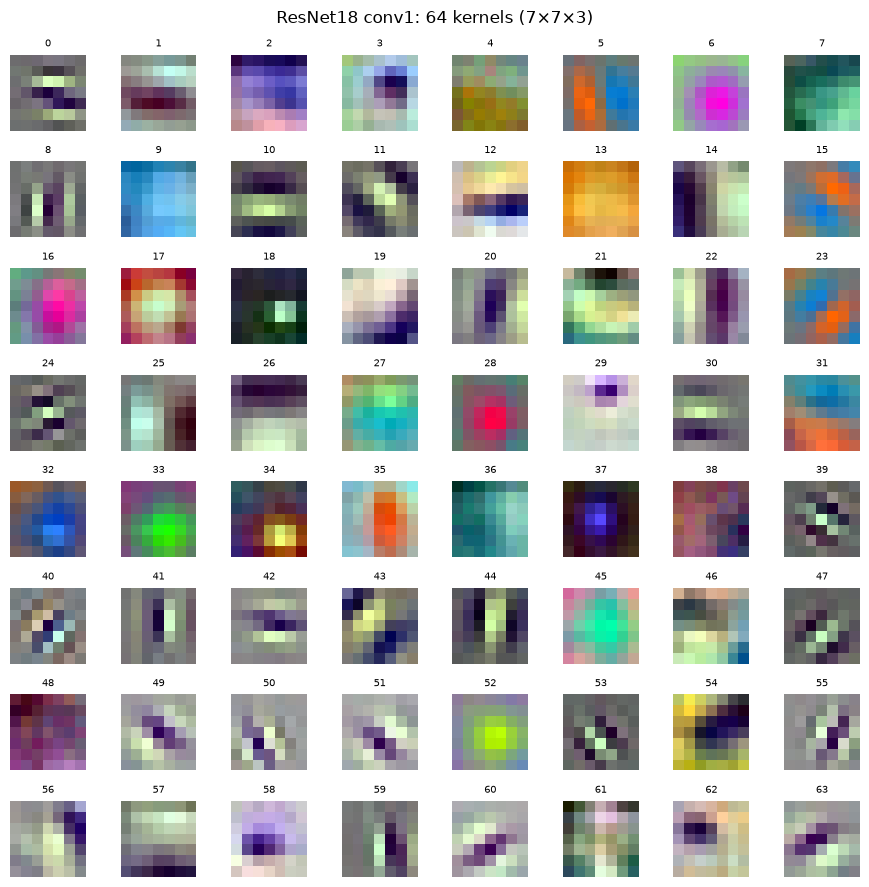

In [37]:
from PIL import Image
from src.data import get_base_tf

vis_model = build_resnet18(pretrained=False).to(device)
vis_model.load_state_dict(torch.load("checkpoints/exp_res_lr1e-4.pt", weights_only=True))
vis_model.eval()

W = vis_model.conv1.weight.detach().cpu()        # 形狀 (64, 3, 7, 7)
print("conv1 kernel shape:", tuple(W.shape))

def norm01(t):                                    # 把數值縮放到 0~1 才能畫成圖
    t = t - t.min()
    return t / (t.max() + 1e-8)

fig, axes = plt.subplots(8, 8, figsize=(9, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(norm01(W[i]).permute(1, 2, 0))      # (3,7,7) → (7,7,3) 才能顯示
    ax.set_title(str(i), fontsize=7); ax.axis("off")
plt.suptitle("ResNet18 conv1: 64 kernels (7×7×3)")
plt.tight_layout(); plt.savefig("results/kernels_all.png", dpi=150); plt.show()

兩個 kernel 的放大圖與 feature map

- Kernel 14 是右亮左暗的垂直分界，feature map 在貓的前腳、身體輪廓與袋子的垂直摺痕處反應強烈，水平方向的區域則反應較弱，推論其用途為偵測垂直方向的邊緣
- Kernel 32 中心為藍色，feature map 都是藍色袋子在發亮，推論其用途為偵測藍色區域

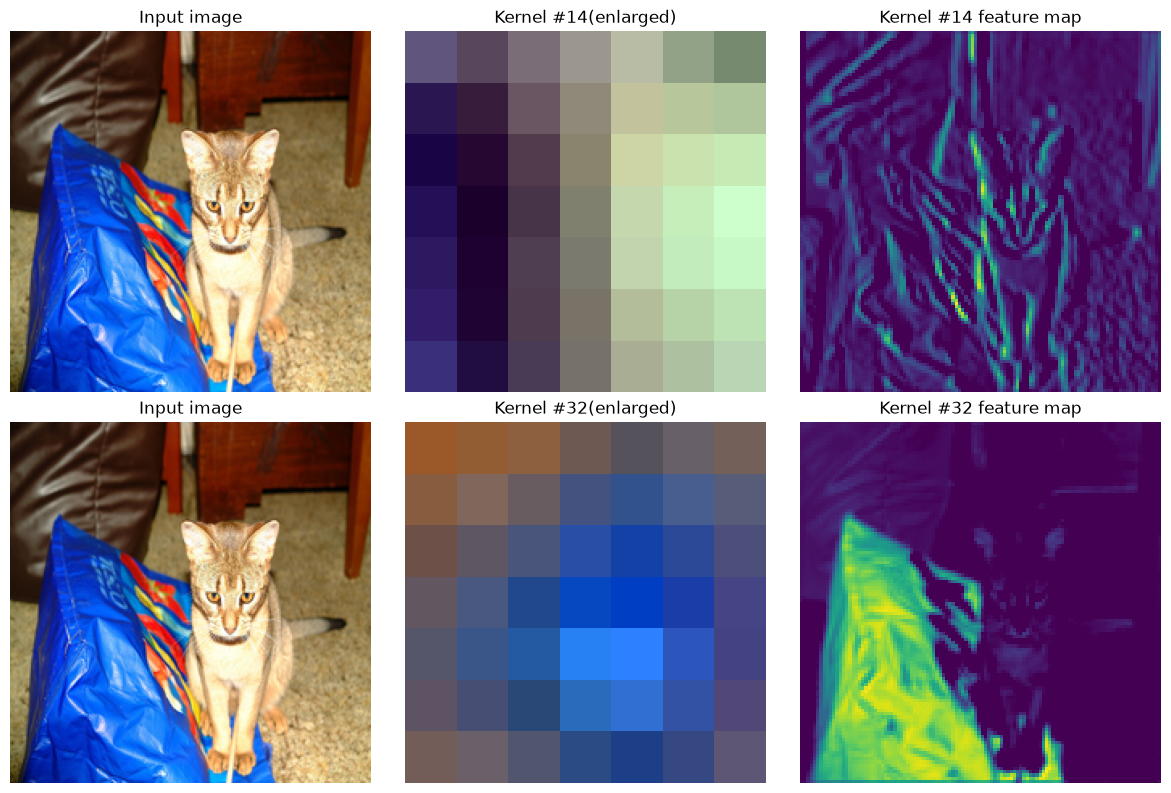

In [ ]:
K1, K2 = 14, 32        

sample_path = df[df["split"] == "test"]["path"].iloc[0]
img = Image.open(sample_path).convert("RGB")
x = get_base_tf()(img).unsqueeze(0).to(device)

with torch.no_grad():
    fmap = torch.relu(vis_model.bn1(vis_model.conv1(x)))[0].cpu()   # (64, 112, 112)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for row, k in enumerate([K1, K2]):
    axes[row, 0].imshow(img.resize((224, 224)));       axes[row, 0].set_title("Input image")
    axes[row, 1].imshow(norm01(W[k]).permute(1, 2, 0), interpolation="nearest")
    axes[row, 1].set_title(f"Kernel #{k}(enlarged)")
    axes[row, 2].imshow(fmap[k], cmap="viridis");    axes[row, 2].set_title(f"Kernel #{k} feature map")
for ax in axes.flat: ax.axis("off")
plt.tight_layout(); plt.savefig("results/kernels_two.png", dpi=150); plt.show()

Grad-CAM 工具與載入 ResNet 18 模型

In [44]:
import torch.nn.functional as F
from PIL import Image
from src.data import get_base_tf

class GradCAM:
    def __init__(self, model, layer):
        self.model, self.acts, self.grads = model, None, None
        def fwd_hook(m, i, o):
            self.acts = o.detach()                                   # 記下特徵圖
            o.register_hook(lambda g: setattr(self, "grads", g.detach()))  # 記下梯度
        layer.register_forward_hook(fwd_hook)

    def __call__(self, x, cls=None):
        self.model.zero_grad()
        out = self.model(x)
        probs = out.softmax(1)[0]
        if cls is None:
            cls = out.argmax(1).item()                               # 預設解釋模型預測的類別
        out[0, cls].backward()                                       # 對該類別分數求梯度
        w = self.grads.mean(dim=(2, 3), keepdim=True)                # 每個通道的重要性
        cam = F.relu((w * self.acts).sum(1))[0]                      # 加權加總,只保留正向貢獻
        cam = F.interpolate(cam[None, None], size=x.shape[2:],
                            mode="bilinear", align_corners=False)[0, 0]
        cam = (cam - cam.min()) / (cam.max() + 1e-8)                 # 縮放到 0~1
        return cam.cpu().numpy(), cls, probs[cls].item()

cam_model = build_resnet18(pretrained=False).to(device)
cam_model.load_state_dict(torch.load("checkpoints/exp_res_lr1e-4.pt", weights_only=True))
cam_model.eval()
gradcam = GradCAM(cam_model, cam_model.layer4)
tf = get_base_tf()

挑出預測正確與錯誤的例子並畫圖

紅黃區域幾乎都落在頭部的位置，代表模型都有正確抓到重點，只是有些品種長得太像，模型本身對這些相似品種也較不確定，導致模型判斷錯誤

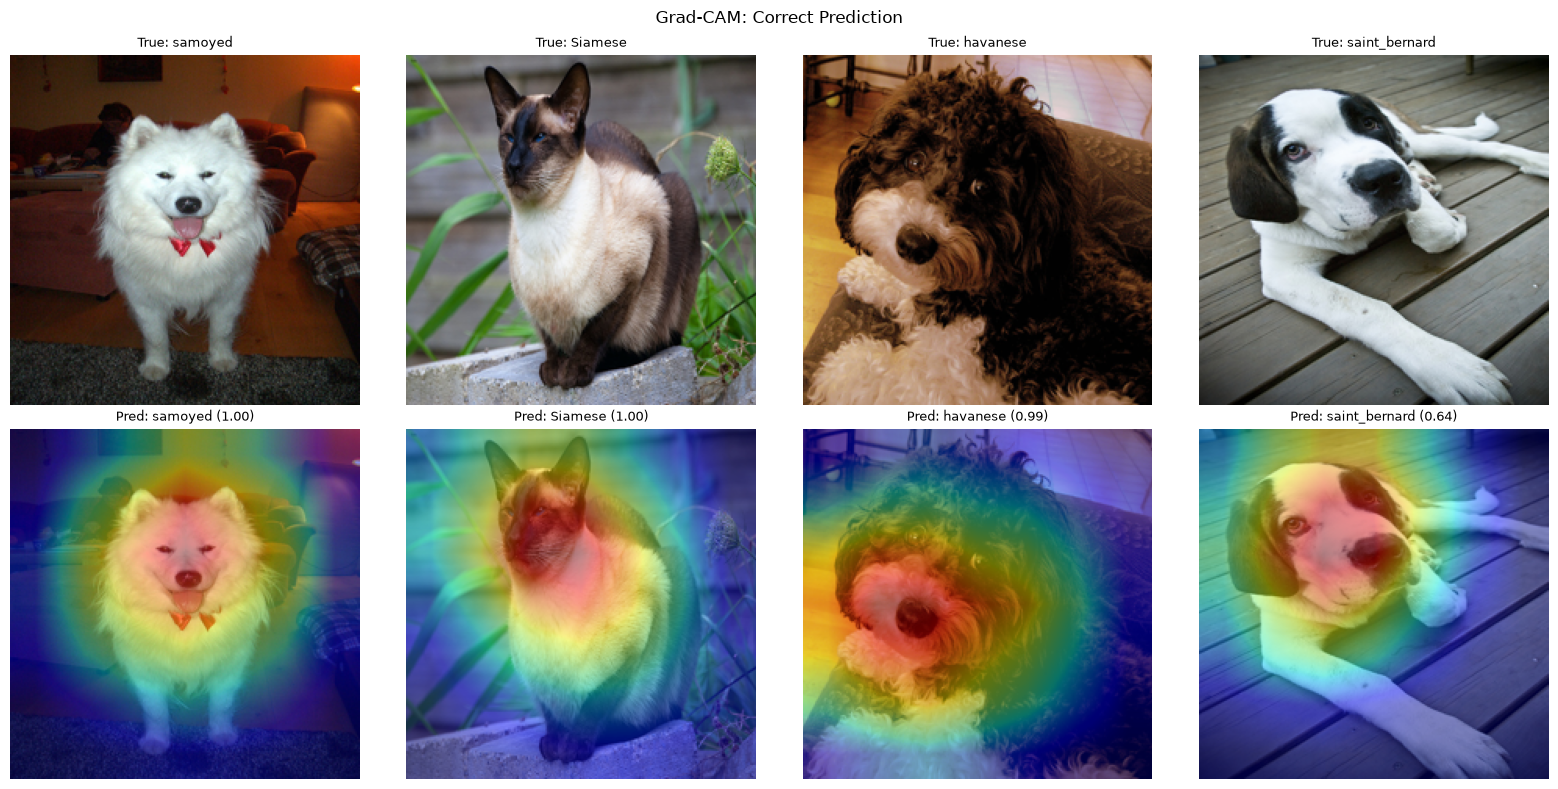

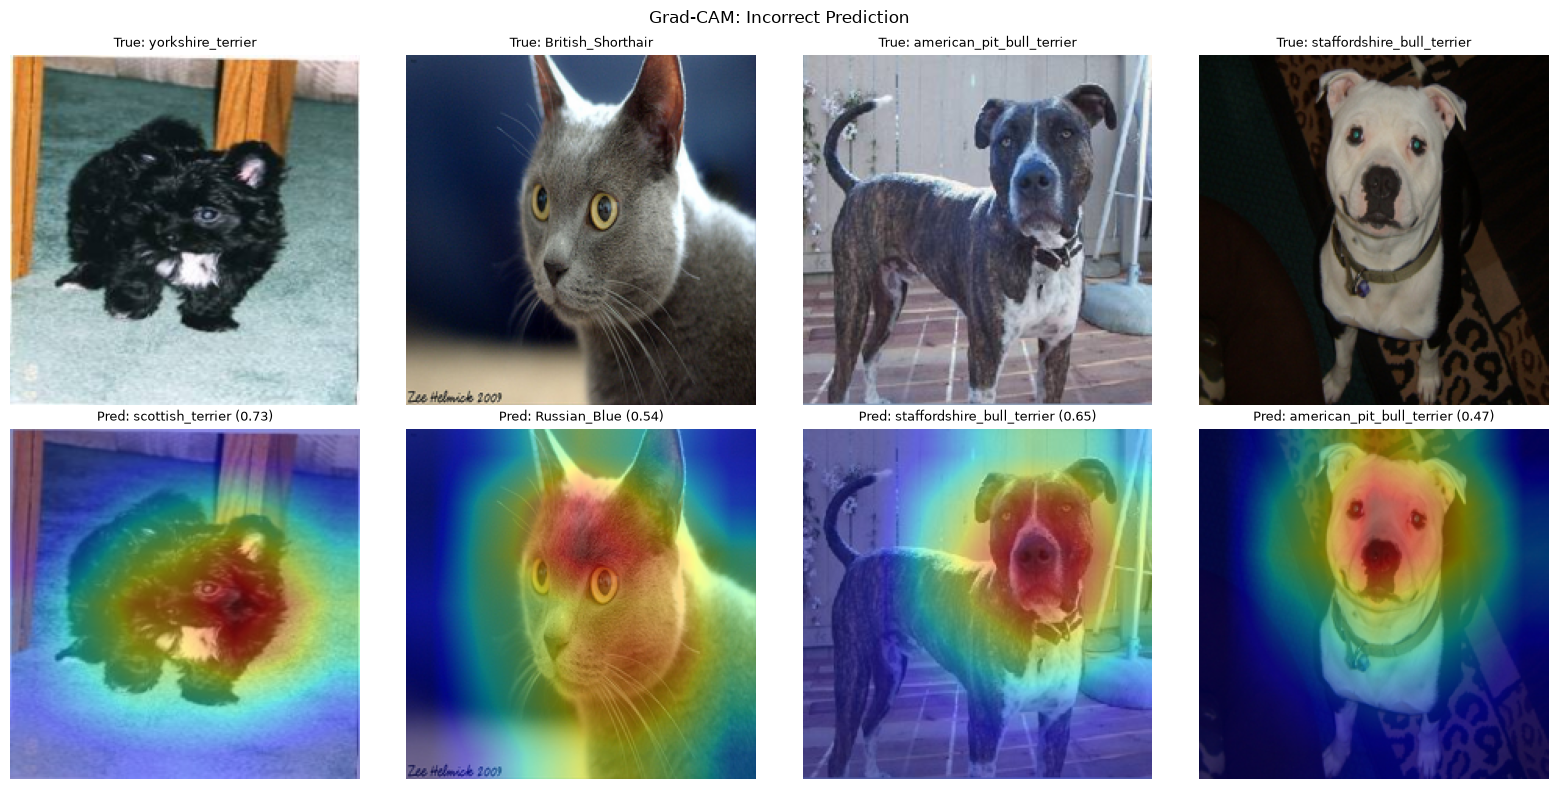

In [45]:
test_rows = df[df["split"] == "test"].sample(frac=1, random_state=0)   # 打亂順序
correct, wrong = [], []
for _, row in test_rows.iterrows():
    img = Image.open(row["path"]).convert("RGB")
    cam, pred, p = gradcam(tf(img).unsqueeze(0).to(device))
    item = (img, cam, row["label"], pred, p)
    if pred == row["label"] and len(correct) < 4: correct.append(item)
    elif pred != row["label"] and len(wrong) < 4: wrong.append(item)
    if len(correct) == 4 and len(wrong) == 4: break

def show_cam(items, title, fname):
    fig, axes = plt.subplots(2, len(items), figsize=(4 * len(items), 8))
    for j, (img, cam, t, pr, p) in enumerate(items):
        im = np.array(img.resize((224, 224)))
        axes[0, j].imshow(im); axes[0, j].set_title(f"True: {class_names[t]}", fontsize=9)
        axes[1, j].imshow(im); axes[1, j].imshow(cam, cmap="jet", alpha=0.45)
        axes[1, j].set_title(f"Pred: {class_names[pr]} ({p:.2f})", fontsize=9)
    for ax in axes.flat: ax.axis("off")
    plt.suptitle(title); plt.tight_layout(); plt.savefig(f"results/{fname}", dpi=150); plt.show()

show_cam(correct, "Grad-CAM: Correct Prediction", "gradcam_correct.png")
show_cam(wrong, "Grad-CAM: Incorrect Prediction", "gradcam_wrong.png")